In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('Pakistan Largest Ecommerce Dataset.csv', low_memory=False)
df.head()
# Dataset loaded successfully
# low_memory=False is used to avoid datatype warning

,item_id,status,created_at,sku,price,qty_ordered,grand_total,increment_id,category_name_1,sales_commission_code,...,Month,Customer Since,M-Y,FY,Customer ID,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,211131.0,complete,7/1/2016,kreations_YI 06-L,1950.0,1.0,1950.0,100147443,Women's Fashion,\N,...,7.0,2016-7,7-2016,FY17,1.0,NaN,NaN,NaN,NaN,NaN
1,211133.0,canceled,7/1/2016,kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...,240.0,1.0,240.0,100147444,Beauty & Grooming,\N,...,7.0,2016-7,7-2016,FY17,2.0,NaN,NaN,NaN,NaN,NaN
2,211134.0,canceled,7/1/2016,Ego_UP0017-999-MR0,2450.0,1.0,2450.0,100147445,Women's Fashion,\N,...,7.0,2016-7,7-2016,FY17,3.0,NaN,NaN,NaN,NaN,NaN
3,211135.0,complete,7/1/2016,kcc_krone deal,360.0,1.0,60.0,100147446,Beauty & Grooming,R-FSD-52352,...,7.0,2016-7,7-2016,FY17,4.0,NaN,NaN,NaN,NaN,NaN
4,211136.0,order_refunded,7/1/2016,BK7010400AG,555.0,2.0,1110.0,100147447,Soghaat,\N,...,7.0,2016-7,7-2016,FY17,5.0,NaN,NaN,NaN,NaN,NaN


Data Preprocessing: [1 Mark]

In [4]:

# Q.1 : Remove all unused columns (if any)

# To Remove unused and empty columns we first have to check if there are such columns

df.info()
print('\n')
print('\n')
df.isnull().sum()
print('\n')
print(df.duplicated().sum())  # Sum of duplicates
print('\n')



<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 26 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   item_id                584524 non-null  float64
 1   status                 584509 non-null  str    
 2   created_at             584524 non-null  str    
 3   sku                    584504 non-null  str    
 4   price                  584524 non-null  float64
 5   qty_ordered            584524 non-null  float64
 6   grand_total            584524 non-null  float64
 7   increment_id           584524 non-null  str    
 8   category_name_1        584360 non-null  str    
 9   sales_commission_code  447346 non-null  str    
 10  discount_amount        584524 non-null  float64
 11  payment_method         584524 non-null  str    
 12  Working Date           584524 non-null  str    
 13  BI Status              584524 non-null  str    
 14   MV                    584524 non-null  str  

In [23]:
# Removing unnecessary column which is not useful
df.dropna(how='all', axis=1, inplace=True)
df.dropna(how='all', axis=0, inplace=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 584524 entries, 0 to 584523
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   item_id                584524 non-null  float64
 1   status                 584524 non-null  object 
 2   created_at             584524 non-null  str    
 3   sku                    584504 non-null  str    
 4   price                  584524 non-null  float64
 5   qty_ordered            584524 non-null  float64
 6   grand_total            584524 non-null  float64
 7   increment_id           584524 non-null  str    
 8   category_name_1        584524 non-null  object 
 9   sales_commission_code  584524 non-null  object 
 10  discount_amount        584524 non-null  float64
 11  payment_method         584524 non-null  str    
 12  Working Date           584524 non-null  str    
 13  BI Status              584524 non-null  str    
 14   MV                    584524 non-null  str    

In [24]:
# Q.2 : Handle Null values (decide whether to remove column, add ‘0’ or mean of feature)
# Ans: First, we check which columns have missing values and how much

null_summary = pd.DataFrame({
    'Null Count': df.isnull().sum(),
    'Percentage (%)': (df.isnull().sum() / len(df)) * 100
})
print(null_summary)

# This table shows how many missing values each column has
# and what percentage of the dataset is missing

                       Null Count  Percentage (%)
item_id                         0        0.000000
status                          0        0.000000
created_at                      0        0.000000
sku                            20        0.003422
price                           0        0.000000
qty_ordered                     0        0.000000
grand_total                     0        0.000000
increment_id                    0        0.000000
category_name_1                 0        0.000000
sales_commission_code           0        0.000000
discount_amount                 0        0.000000
payment_method                  0        0.000000
Working Date                    0        0.000000
BI Status                       0        0.000000
 MV                             0        0.000000
Year                            0        0.000000
Month                           0        0.000000
Customer Since                  0        0.000000
M-Y                             0        0.000000


In [20]:
# Step 4: Handle Null Values

numeric_cols = ['grand_total', 'price', 'qty_ordered']
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())  # Fill numeric nulls with mean

categorical_cols = ['status', 'payment_method', 'category_name_1', 'sales_commission_code', 'Customer Since']
for col in categorical_cols:
    df[col] = df[col].fillna(0)  # Fill categorical nulls with 0
    # Categorical missing filled with 0

    null_summary = pd.DataFrame({
    'Null Count': df.isnull().sum(),
    'Percentage (%)': (df.isnull().sum() / len(df)) * 100
})
print(null_summary)


                       Null Count  Percentage (%)
item_id                         0        0.000000
status                          0        0.000000
created_at                      0        0.000000
sku                            20        0.003422
price                           0        0.000000
qty_ordered                     0        0.000000
grand_total                     0        0.000000
increment_id                    0        0.000000
category_name_1                 0        0.000000
sales_commission_code           0        0.000000
discount_amount                 0        0.000000
payment_method                  0        0.000000
Working Date                    0        0.000000
BI Status                       0        0.000000
 MV                             0        0.000000
Year                            0        0.000000
Month                           0        0.000000
Customer Since                  0        0.000000
M-Y                             0        0.000000


In [27]:
# Step 5: Remove duplicates
df.drop_duplicates(inplace=True)

# Now since there are 23% null values in sales_commission_code or more specific (1.LC 37K) records it's better to just remove that column
df.drop(columns=['sales_commission_code'], inplace=True)

# and we have null's in status, sku, category, customer since and customer id which we will handle.
df.describe()   # I'll be adding mean values in the empty columns

df['Customer ID'] = df['Customer ID'].fillna(df['Customer ID'].mean())

In [28]:
 # step 6: Handle Categorical Features
df['status'] = df['status'].fillna('Unknown')
df['sku'] = df['sku'].fillna('Unknown')
df['category_name_1'] = df['category_name_1'].fillna('Unknown')
df['Customer Since'] = df['Customer Since'].fillna('Unknown')


print("Remaining Nulls per Column:")
print(df[['status', 'sku', 'category_name_1', 'Customer Since', 'Customer ID']].isnull().sum())

Remaining Nulls per Column:
status             0
sku                0
category_name_1    0
Customer Since     0
Customer ID        0
dtype: int64


In [29]:
#  Correlation Analysis

# Step 1: Get correlation of all numeric features with 'grand_total'
correlations = df.select_dtypes(include=['number']).corr()['grand_total'].abs().sort_values(ascending=False)

# Display top 5 features (excluding grand_total itself)
print("Top 5 features most correlated with grand_total:")
print(correlations[1:6])

Top 5 features most correlated with grand_total:
qty_ordered        0.753487
price              0.277607
discount_amount    0.104825
Customer ID        0.054043
item_id            0.049265
Name: grand_total, dtype: float64


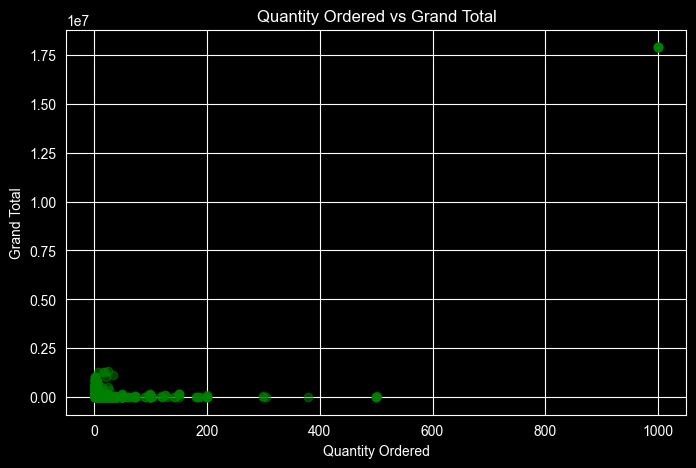

In [30]:
# Step 2: Scatter plot for two important features: qty_ordered vs grand_total
plt.figure(figsize=(8,5))
plt.scatter(df['qty_ordered'], df['grand_total'], alpha=0.5, color='green')
plt.title('Quantity Ordered vs Grand Total')
plt.xlabel('Quantity Ordered')
plt.ylabel('Grand Total')
plt.show()

# Redundant features: item_id, Customer ID
# These are just identifiers and do not help predict grand_total

# Features aligned most with target: qty_ordered, price
# Higher quantity and higher price naturally lead to higher grand_total

In [31]:
# Q.6 : Handle Outliers
# Answer : To handle outliers simply, we focus on the grand_total column.
# Outliers are extreme values (like a $1 million order in a store where most orders are $50)


limit = df['grand_total'].quantile(0.99)     # Find the 99% cutoff point

df = df[df['grand_total'] <= limit]          # Keep only the data below

print("Outliers removed. New maximum grand_total is:", df['grand_total'].max())

Outliers removed. New maximum grand_total is: 89899.0


Now for Data Analytics [1Mark]

In [32]:
# Step 1: Best-selling category
# Group by 'category_name_1' and sum 'qty_ordered'
category_sales = df.groupby('category_name_1')['qty_ordered'].sum().sort_values(ascending=False)

print("Best-selling categories (top 5):")
print(category_sales.head(5))

# The category with the highest total quantity sold is the best-selling category

Best-selling categories (top 5):
category_name_1
Mobiles & Tablets    120573.0
Men's Fashion        101367.0
Others                84571.0
Superstore            82423.0
Women's Fashion       63071.0
Name: qty_ordered, dtype: float64


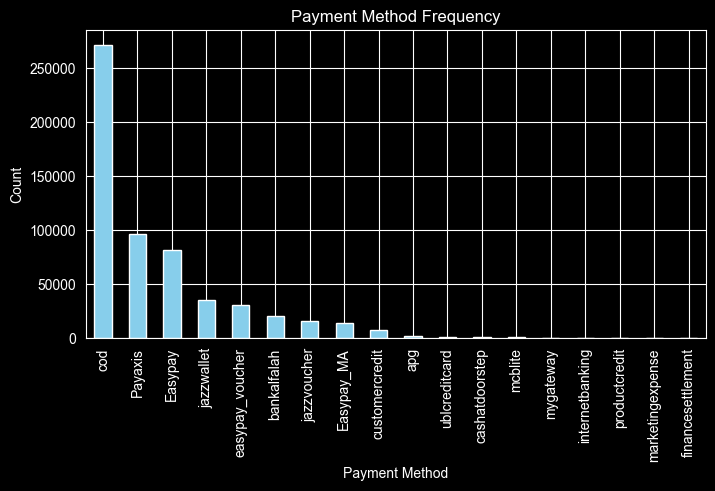

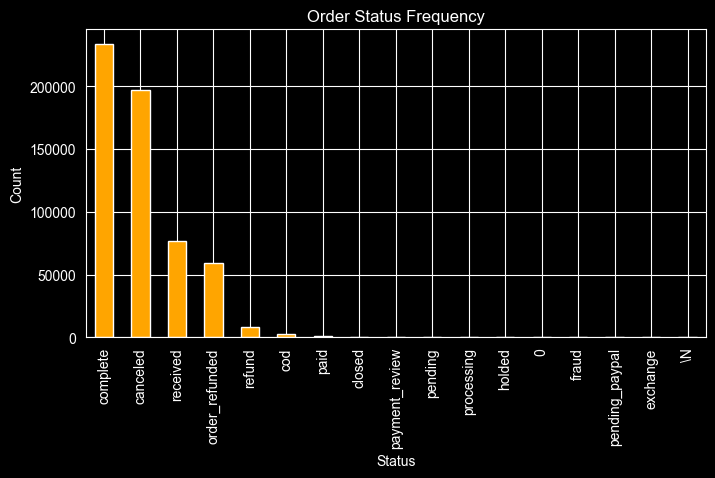

In [36]:
# Step 2: Visualize payment method and order status frequency
import matplotlib.pyplot as plt

# Payment method frequency
plt.figure(figsize=(8,4))
df['payment_method'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Payment Method Frequency')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.show()

print('\n')
print('\n')
# Order status frequency
plt.figure(figsize=(8,4))
df['status'].value_counts().plot(kind='bar', color='orange')
plt.title('Order Status Frequency')
plt.xlabel('Status')
plt.ylabel('Count')
plt.show()

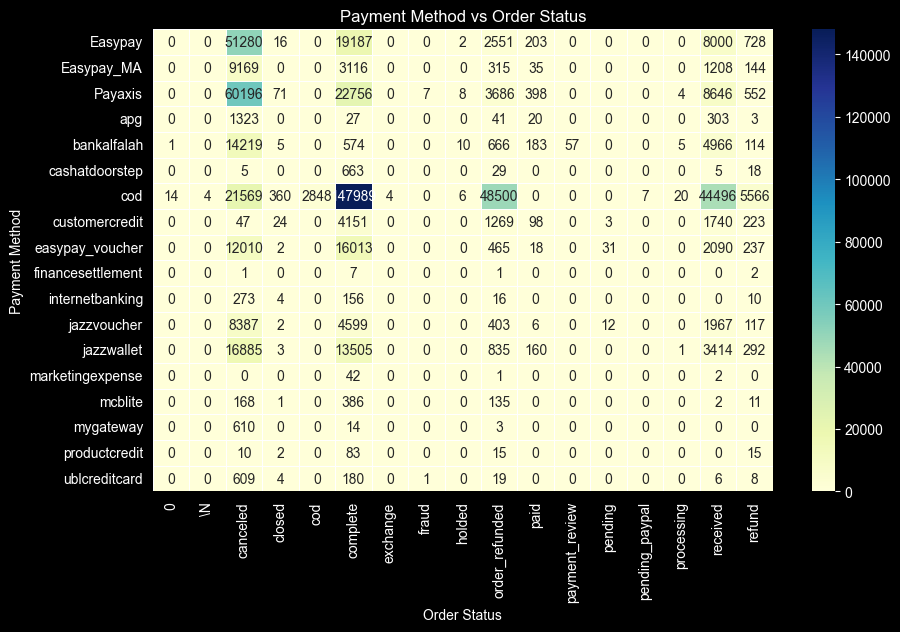

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 3: Correlation between payment method and order status (visualization)
payment_status_corr = pd.crosstab(df['payment_method'], df['status'])

plt.figure(figsize=(10,6))
sns.heatmap(payment_status_corr, annot=True, fmt='d', cmap='YlGnBu', linewidths=0.5)
plt.title('Payment Method vs Order Status')
plt.xlabel('Order Status')
plt.ylabel('Payment Method')
plt.show()

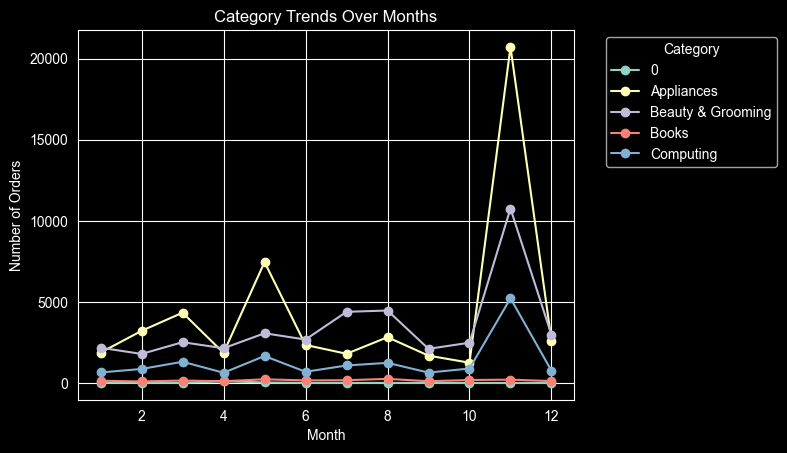

In [42]:
# Step 4: Correlation between order date and item category
# First, ensure 'Working Date' is datetime type
date_category_table = pd.crosstab(df['Month'], df['category_name_1'])           # Create a table of Month vs Category
date_category_table.iloc[:, :5].plot(kind='line', marker='o')                   # Plot the trends for the Top 5 categories

plt.title('Category Trends Over Months')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


In [45]:
# Step 5: Hidden patterns (example)
#  A hidden pattern is that highly discounted items are canceled more often,
#       showing that cheap doesn't always lead to a successful sale. Also,
#       even though a layman might focus on expensive products, the data shows that
#       selling many small items Quantity is what actually drives the most revenue.

# Simple comparison of Average Discount by Order Status

print(df.groupby('status')['discount_amount'].mean().sort_values)


<bound method Series.sort_values of status
0                   13.333333
\N                   0.000000
canceled           613.804096
closed             257.734433
cod                 12.113209
complete           502.670027
exchange             0.000000
fraud                0.000000
holded              59.711538
order_refunded     194.180756
paid               257.617867
payment_review     578.215789
pending           1929.008261
pending_paypal       0.000000
processing          33.831000
received           392.464952
refund             337.331597
Name: discount_amount, dtype: float64>


In [46]:
# This saves my cleaned data into new file
df.to_csv('cleaned_data.csv', index=False)

print("File 'cleaned_data.csv' has been created!")

File 'cleaned_data.csv' has been created!
